## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.gridspec as gridspec
import itertools
import seaborn as sns
from sklearn import linear_model

In [3]:
penguins_data = "https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw04-knn-linreg/penguins_data.csv"
data = pd.read_csv(penguins_data)
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [4]:
data.shape

(344, 11)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              344 non-null    object 
 1   Island               344 non-null    object 
 2   Clutch Completion    344 non-null    object 
 3   Date Egg             344 non-null    int64  
 4   Culmen Length (mm)   342 non-null    float64
 5   Culmen Depth (mm)    342 non-null    float64
 6   Flipper Length (mm)  342 non-null    float64
 7   Body Mass (g)        342 non-null    float64
 8   Sex                  334 non-null    object 
 9   Delta 15 N (o/oo)    330 non-null    float64
 10  Delta 13 C (o/oo)    331 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 29.7+ KB


Можно заметить, что в датасете присутствуют пропуски для следующих признаков:
Culmen Length (mm), Culmen Depth (mm), Flipper Length (mm), Body Mass (g), Sex, Delta 15 N (o/oo) и Delta 13 C (o/oo). Удалим строки, которые содержат нулевые значения, а также удалим строку с индексом 43, которая в поле Sex содержит точку:


In [6]:
data = data.drop(index=43)
data.dropna(inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              324 non-null    object 
 1   Island               324 non-null    object 
 2   Clutch Completion    324 non-null    object 
 3   Date Egg             324 non-null    int64  
 4   Culmen Length (mm)   324 non-null    float64
 5   Culmen Depth (mm)    324 non-null    float64
 6   Flipper Length (mm)  324 non-null    float64
 7   Body Mass (g)        324 non-null    float64
 8   Sex                  324 non-null    object 
 9   Delta 15 N (o/oo)    324 non-null    float64
 10  Delta 13 C (o/oo)    324 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 30.4+ KB


В результате было удалено 16 строк, которые содержали пропуски. Теперь закодируем категориальные признаки: Species, Island, Clutch Completion, Sex. Признаки Clutch Completion и Sex являются бинарными, поэтому их можно закодировать 0 и 1. Для этого воспользуемся one hot encoding, а затем удалим один из получившихся столбцов.

Для признака Sex: 0 - female, 1 - male

для признака Clutch Completion: 0 - no, 1 - yes

In [7]:
data = pd.get_dummies(data, columns=["Sex", "Clutch Completion"], drop_first=True, dtype=int)

In [8]:
data = data.drop(["Sex_MALE"], axis=1)
data = data.rename(columns={"Sex_FEMALE": "Sex", "Clutch Completion_Yes": "Clutch Completion"})
data.head()

,Species,Island,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Sex,Clutch Completion
0,Chinstrap,Dream,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0,1
1,Chinstrap,Dream,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,1,1
2,Gentoo,Biscoe,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1,1
3,Chinstrap,Dream,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,1,1
4,Gentoo,Biscoe,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1,1


In [9]:
data["Island"].unique()

array(['Dream', 'Biscoe', 'Torgersen'], dtype=object)

Признак Island содержит 3 уникальных значения. Поскольку названия островов не имеют никакого порядка, необходимо закодировать их с помощью one-hot-encoding:

In [10]:
data = pd.get_dummies(data, columns=["Island"], drop_first=True, dtype = int)

In [11]:
data.head()

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Sex,Clutch Completion,Island_Dream,Island_Torgersen
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,0,1,1,0
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,1,1,1,0
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,1,1,0,0
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,1,1,1,0
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,1,1,0,0


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [12]:
enc = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data['Species'] = enc.fit_transform(data[['Species']])

In [13]:
y = data['Species']
x = data.drop(['Species'], axis=1)

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [14]:
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

**Ответ:** При разбиении данных на обучающую и тестовую выборку может оказаться, что разделение по классам в выборке не сбалансированное. Например, если в выборку попадет 90 записей для вида Gentoo и только 10 для Adelie, модель с большой вероятностью будет ошибаться при классификации второго вида. Поэтому важно, чтобы соотношение классов в выборке было схоже с их соотношением во всем датасете.

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [15]:
normalizer = StandardScaler()
x_train_norm = normalizer.fit_transform(x_train)
x_train = pd.DataFrame(data=x_train_norm, columns=x_train.columns)
x_train.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Sex,Clutch Completion,Island_Dream,Island_Torgersen
0,-1.204110,1.321614,-0.411920,2.054179,1.599895,0.084808,-0.081095,-1.017859,0.336601,-0.747409,-0.406138
1,1.315921,0.451606,-0.919521,1.262076,1.227775,-0.953624,0.336021,-1.017859,0.336601,-0.747409,-0.406138
2,0.133471,0.977236,-1.071801,1.046048,0.669596,-0.881619,-1.340963,-1.017859,0.336601,-0.747409,-0.406138
3,0.116235,0.179728,-1.680922,0.974038,0.669596,-0.916070,-1.195652,0.982455,0.336601,-0.747409,-0.406138
4,0.088656,-0.527154,1.618483,-0.538158,-0.818883,0.759443,-0.499473,-1.017859,0.336601,1.337955,-0.406138


In [16]:
normalizer = StandardScaler()
x_test_norm = normalizer.fit_transform(x_test)
x_test = pd.DataFrame(data=x_test_norm, columns=x_test.columns)
x_test.head()

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Sex,Clutch Completion,Island_Dream,Island_Torgersen
0,0.077009,-0.900536,0.188482,-1.061735,-0.840253,-0.293348,-0.526614,1.041684,0.355580,-0.795822,-0.337100
1,0.106721,-1.239969,1.163350,-1.203977,-0.410094,-0.668017,-1.019172,-0.959984,0.355580,-0.795822,2.966479
2,-1.134584,-1.428542,0.034555,-0.990614,-1.331864,0.521361,-0.687171,1.041684,-2.812311,-0.795822,2.966479
3,1.305108,-0.806249,-0.221989,-1.630703,-1.208961,1.653722,0.730557,1.041684,0.355580,1.256562,-0.337100
4,0.113324,0.532625,-1.504711,0.645169,0.757482,-0.620463,-1.563686,1.041684,0.355580,-0.795822,-0.337100


In [17]:
neighbors = [1, 3, 5, 10, 15, 25]
x_train1 = x_train[['Flipper Length (mm)', 'Body Mass (g)']]
x_test1 = x_test[['Flipper Length (mm)', 'Body Mass (g)']]
print("NN	Train	Test")
for n in neighbors:
    clf = KNeighborsClassifier(n_neighbors=n, p = 2)
    clf.fit(x_train1, y_train)
    y_predicted_train = clf.predict(x_train1)
    accuracy_train = accuracy_score(y_train, y_predicted_train)
    y_predicted_test = clf.predict(x_test1)
    accuracy_test = accuracy_score(y_test, y_predicted_test)
    print(f'{n}       {accuracy_train:.2f}    {accuracy_test:.2f}')

NN	Train	Test
1       0.97    0.74
3       0.86    0.77
5       0.82    0.78
10       0.82    0.81
15       0.81    0.80
25       0.81    0.81


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [18]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [19]:
import mlxtend
from mlxtend.plotting import plot_decision_regions

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

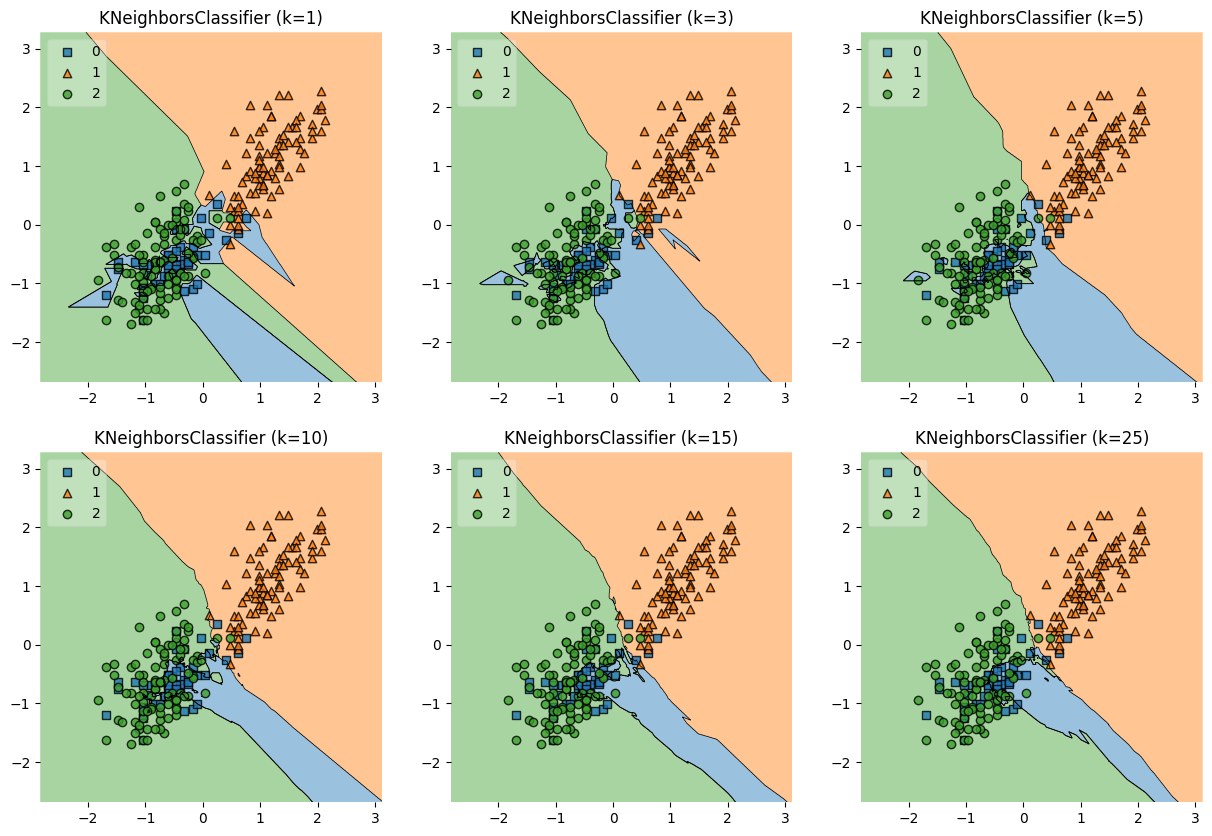

In [29]:
neighbors = [1, 3, 5, 10, 15, 25]
x_train1_array = x_train1.to_numpy()
y_train_array = y_train.to_numpy().astype(int)
labels = ['KNeighborsClassifier (k=1)', 'KNeighborsClassifier (k=3)', 'KNeighborsClassifier (k=5)',
          'KNeighborsClassifier (k=10)', 'KNeighborsClassifier (k=15)', 'KNeighborsClassifier (k=25)']
clf1 = KNeighborsClassifier(n_neighbors=1, p = 2)
clf3 = KNeighborsClassifier(n_neighbors=3, p = 2)
clf5 = KNeighborsClassifier(n_neighbors=5, p = 2)
clf10 = KNeighborsClassifier(n_neighbors=10, p = 2)
clf15 = KNeighborsClassifier(n_neighbors=15, p = 2)
clf25 = KNeighborsClassifier(n_neighbors=25, p = 2)

gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(15,10))
for clf, lab, grd in zip([clf1, clf3, clf5, clf10, clf15, clf25],labels,itertools.product([0, 1, 2], repeat=2)):
    clf.fit(x_train1_array, y_train_array)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=x_train1_array, y=y_train_array, clf=clf, legend=2)
    plt.title(lab)

plt.show()


**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

**Ответ:**

При N = 1 метод ближайших соседей наиболее точно классифицирует пингвинов на обучающей выборке, это можно заметить по доле правильных ответов 0.97. Однако на тестовых данных доля правильных ответов равна 0.74. Это возникает из-за того, что модель ориентируется только на одного соседа и, если этот сосед является выбросом, модель неверно определяет класс объекта. Такая разница в accuracy свидетельствует о явном переобучении, так как модель хорошо ведет себя на обучающих данных, но плохо работает на новых. Решающая поверхность для такой модели получается рваная. Видно, что для некоторых объектов класс определяется неверно, например, синий квадрат, который находится в зеленой области, вероятнее всего должен быть зеленым, но из-за близости с другим синим объектом был отнесен к этому классу.

При N = 3, 5 доля правильных ответов на тестовой выборке становится чуть выше, рваных поверхностей не так много, однако они все еще присутствуют.

При N = 10, 15 и 25 доля правильных ответов на тестовой выборке близка к значению на обучающей, что говорит об отсутствии переобучения. Границы классов на решающей поверхности более сглаженные, вследствие чего реже будут возникать ситуации, когда из-за выбросов и шумов, объекту будет присваиваться неверный класс.

Сильно большое количество соседей может привести к тому, что влияние некоторых признаков станет незначительным и они перестанут учитываться моделью, поэтому
**в качестве оптимального числа соседей можно выбрать число 10, так как для него решающая поверхность менее рваная и accuracy на для обучающей и тестовой выборки практически совпадают (0.82 и 0.81).**

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

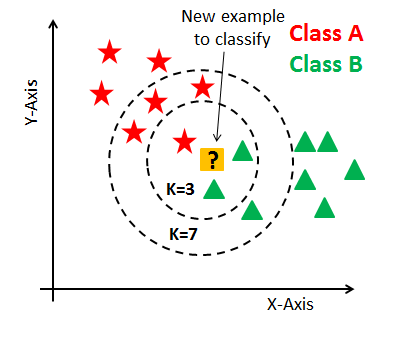

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [36]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
      self.x_train = X
      self.y_train = y

    def predict(self, X):
      result = []
      for x_test in X:
        distances = self.count_distance(self.x_train, x_test)
        sort_distances = np.argsort(distances)
        k_neighbors_index = sort_distances[:self.k]
        k_neighbors_answer = self.y_train[k_neighbors_index]
        result.append(Counter(k_neighbors_answer).most_common(1)[0][0])
      return np.array(result)

    def count_distance(self, x, y):
      dist = np.linalg.norm(x - y, axis = 1)
      return dist

In [37]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [38]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [39]:
x_test_array = x_test.to_numpy().astype(int)
y_test_array = y_test.to_numpy().astype(int)
x_train_array = x_train.to_numpy().astype(int)
results = np.array([[0,0]])
for n in neighbors:
  knn = KNN(k=n)
  knn.fit(x_train_array, y_train_array)
  accuracy = (y_test_array == knn.predict(x_test_array)).mean()
  results = np.append(results, [[n, accuracy]], axis=0)
max_index = np.argmax(results[:, 1])
mx_k = results[max_index, 0]
mx_accuracy = results[max_index, 1]

print(f'Лучшее k: {mx_k} с точностью {mx_accuracy} на test.')

Лучшее k: 10.0 с точностью 0.9591836734693877 на test.


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [40]:
diamonds_data = "https://github.com/hse-ds/iad-intro-ds/raw/master/2025/homeworks/hw04-knn-linreg/diamonds.csv"
data = pd.read_csv(diamonds_data)
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [41]:
data.shape

(53940, 11)

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


**Пояснение:** можно заметить, что каждый признак содержит 53940 ненулевых строк, следовательно, пропущенные значения отсутствуют в датасете.

В наборе данных есть бессмысленный столбец 'Unnamed: 0', который не несет в себе полезной информации, поэтому его стоит удалить. Также можно удалить столбец depth, поскольку глубина бриллианта учитывается в признаке z, а depth полностью зависит от признаков x,y,z и не несет дополнительной информации.

In [43]:
data = data.drop(columns=['Unnamed: 0'])
data = data.drop(columns=['depth'])
data.head(5)

,carat,cut,color,clarity,table,price,x,y,z
0,0.23,Ideal,E,SI2,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

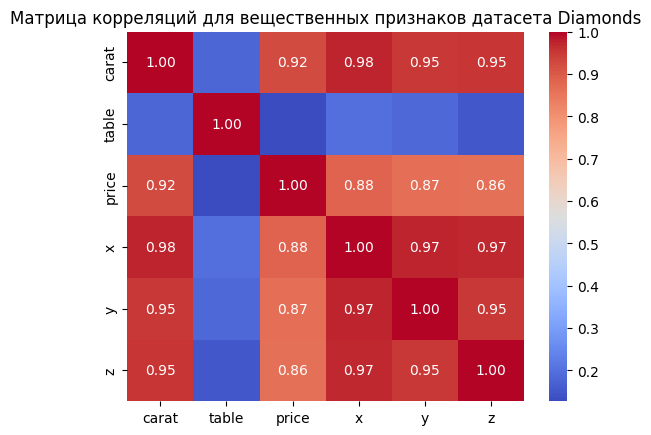

In [44]:
plt.title('Матрица корреляций для вещественных признаков датасета Diamonds')
real_data = data.corr(numeric_only=True)
axes = sns.heatmap(real_data, cmap='coolwarm', annot=True, fmt="0.2f")
for t in axes.texts:
    if abs(float(t.get_text())) >= 0.5:
        t.set_text(t.get_text())
    else:
        t.set_text("")

**Ответ:**

Наибольшую корреляцию с целевой переменной price имеет признак carat. Корреляция равна 0.92. Следовательно цена во многом зависит от веса бриллианта: чем больше вес, тем выше цена.

Также высокая корреляция наблюдается между целевой переменной и размерами бриллианта(признаки x, y, z). Так происходит потому что вес напрямую зависит от длины, ширины и глубины бриллианта (высокая корреляция 0.98, 0.95, 0.95), а цена зависит от веса.

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [45]:
enc = OrdinalEncoder(categories=[['J', 'I', 'H', 'G', 'F', 'E', 'D' ]])
data['color'] = enc.fit_transform(data[['color']])

In [46]:
enc = OrdinalEncoder(categories=[['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']])
data['clarity'] = enc.fit_transform(data[['clarity']])

In [47]:
enc = OrdinalEncoder(categories=[['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']])
data['cut'] = enc.fit_transform(data[['cut']])
data.head(5)

,carat,cut,color,clarity,table,price,x,y,z
0,0.23,4.0,5.0,1.0,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,58.0,335,4.34,4.35,2.75


**Пояснение:**

Признаки color, cut и clarity - это категориальные признаки, которые имеют порядок (от худшего к лучшему), целесообразнее закодировать их с помощью OrdinalEncoder, где 1 - худшее значение.



**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [48]:
y = data['price']
x = data.drop(['price'], axis=1)

In [49]:
np.random.seed(42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [50]:
normalizer = StandardScaler()
x_train_norm = normalizer.fit_transform(x_train)
x_train = pd.DataFrame(data=x_train_norm, columns=x_train.columns)
x_train.head()

,carat,cut,color,clarity,table,x,y,z
0,0.862659,0.982948,-0.825977,1.184867,-0.207099,1.055581,0.986556,0.968253
1,-1.029889,0.982948,0.938373,-0.030994,-0.656213,-1.207734,-1.202544,-1.168276
2,0.862659,0.982948,0.938373,0.576936,-0.207099,0.904099,0.951670,0.982309
3,0.021527,0.982948,0.350256,-1.246854,-1.105327,0.164512,0.192898,0.251391
4,-0.020530,0.982948,-1.414093,1.184867,-0.656213,0.182333,0.184176,0.181110


In [51]:
normalizer = StandardScaler()
x_test_norm = normalizer.fit_transform(x_test)
x_test = pd.DataFrame(data=x_test_norm, columns=x_test.columns)
x_test.head()

,carat,cut,color,clarity,table,x,y,z
0,-1.177152,0.978051,-0.240174,1.784795,-0.642780,-1.562934,-1.523982,-1.536090
1,-0.454302,-0.808070,0.347087,1.179553,-0.198865,-0.251053,-0.269090,-0.394598
2,-0.836987,0.978051,0.934347,1.179553,-1.086695,-0.857909,-0.870024,-0.842525
3,-0.773206,0.084990,0.934347,1.179553,-0.198865,-0.715120,-0.737465,-0.799177
4,1.607947,0.978051,0.934347,-1.241416,-1.086695,1.533821,1.454177,1.556054


**Ответ:**

Если признаки не масштабированы, то нельзя утверждать, что, чем больше коэффициент при признаке, тем сильнее его влияние на прогноз, поскольку коэффицент в таком случае отражает не только важность признака, но и его масштаб.

После масштабирования признаков можно утверждать, что признаки с большими коэффициентами наиболее важны для модели.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [52]:
def MSE(y: np.array, y_pred: np.array):
    return ((y - y_pred) ** 2).mean()

reg = linear_model.LinearRegression()
reg.fit(x_train, y_train)
y_predict_train = reg.predict(x_train)
mse_train = MSE(np.array(y_train), np.array(y_predict_train))
print(f'Среднекватратичная ошибка для train: {mse_train}')
y_predict_test = reg.predict(x_test)
mse_test = MSE(np.array(y_test), np.array(y_predict_test))
print(f'Среднекватратичная ошибка для test: {mse_test}')

Среднекватратичная ошибка для train: 1503740.2608821336
Среднекватратичная ошибка для test: 1456145.457550938


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [53]:
reg.coef_

array([5002.74097045,  171.36118322,  555.05660555,  837.71890018,
        -17.08856437, -756.66629265,   62.33093357, -158.09418883])

**Ответ:**

Признаки, для которых коэффициенты по модулю на порядок превышают оценки других вещественных переменных: carat(5002.74097045), clarity(837.71890018) и x(756.66629265).

Вес бриллианта (carat) сильнее всего влияет на целевую переменную, поэтому и коэффициент перед данным признаком самый большой. Признак x отвечает за длину бриллианта, признак clarity - за прозрачность. По всей видимости они также оказывают сильное влияние на прогноз модели.

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [54]:
lasso = linear_model.Lasso(alpha=10)
lasso.fit(x_train, y_train)
lasso.coef_

array([4581.64015242,  158.51075038,  533.98310905,  834.52018095,
        -17.02186424, -329.34808488,   -0.        , -111.25704824])

In [55]:
ridge = linear_model.Ridge(alpha=10)
ridge.fit(x_train, y_train)
ridge.coef_

array([4971.46368717,  170.66157252,  554.01508077,  837.79373055,
        -17.7187765 , -724.00646708,   59.46187525, -157.47966749])

**Ответ:**

В результате применения Lasso-регрессии заметно уменьшились веса для взаимосвязанных признаков carat и x (примерно на 300-400 единиц). Это может говорить о том, что в изначальной регрессии была проблема мультколлинеарности и она проявлялась достаточно сильно, из-за чего сложно было понять отдельное влияние каждого из признаков на цену бриллианта.
Кроме того, для признака **y** коэффициент обнулился. Это значит, что данный признак практически не влияет на целевую переменную.

В результате применения Ridge-регрессии веса изменились незначительно(на 30-40 единиц), что может говорить о том, что хоть в данных и присутствовала мультиколлинеарность, влияние признаков carat и x на целевую переменную все еще остается значительным.


**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

In [56]:
lasso_euclidean_norm = []
parameters = [0.1, 1, 10, 100, 200]
for a in parameters:
  lasso = linear_model.Lasso(alpha=a)
  lasso.fit(x_train, y_train)
  euclidean_norm = np.linalg.norm(lasso.coef_)
  lasso_euclidean_norm.append(euclidean_norm)

In [57]:
ridge_euclidean_norm = []
for a in parameters:
  ridge = linear_model.Ridge(alpha=a)
  ridge.fit(x_train, y_train)
  euclidean_norm = np.linalg.norm(ridge.coef_)
  ridge_euclidean_norm.append(euclidean_norm)

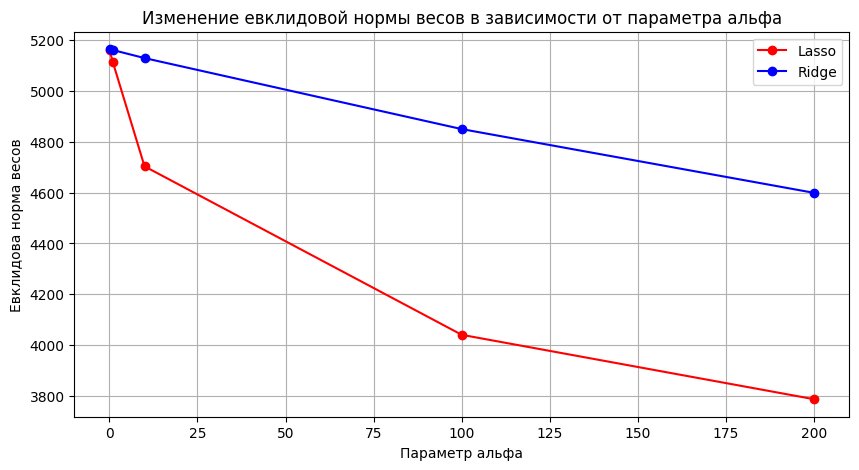

In [58]:
plt.figure(figsize=(10, 5))
plt.plot(parameters, lasso_euclidean_norm, marker='o', label='Lasso', color='red')
plt.plot(parameters, ridge_euclidean_norm, marker='o', label='Ridge', color='blue')
plt.legend()
plt.grid()
plt.xlabel('Параметр альфа')
plt.ylabel('Евклидова норма весов')
plt.title('Изменение евклидовой нормы весов в зависимости от параметра альфа')
plt.show()

**Ответ:**

По графику видно, что Lasso-регрессия сильнее снижает норму коэффициентов. Это происходит за счет того, что Lasso-регрессия использует манхэттенскую норму и зануляет некоторые веса. Это позволяет отбросить некоторые признаки и провести их отбор.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [59]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

reg = linear_model.LassoCV(cv=5, alphas=parameters, random_state=42)
reg.fit(x_train, y_train)
alphas= reg.alphas_

mse_matr = reg.mse_path_
mean_mse = mse_matr.mean(axis=1)

min_mse_index = np.argmin(mean_mse)
res_alpha = alphas[min_mse_index]
res_mse = np.min(mean_mse)

print(f"Наибольшее кчество модели достигается при a = {res_alpha}")
print(f"Среднеквадратичная ошибка при этом равна: {res_mse}")

Наибольшее кчество модели достигается при a = 10.0
Среднеквадратичная ошибка при этом равна: 1515084.6778876204


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [60]:
lasso = linear_model.Lasso(alpha=10.0)
lasso.fit(x_train, y_train)
coefficients = lasso.coef_
print(f'Коэффициенты: {coefficients}')

Коэффициенты: [4581.64015242  158.51075038  533.98310905  834.52018095  -17.02186424
 -329.34808488   -0.         -111.25704824]


**Ответ:**

Наиболее информативными оказались признаки:
1. carat - вес бриллианта. Вполне логично, что более тяжелые бриллианты будут иметь более высокую стоимость, то есть вес - основной параметр, влияющий на цену.
2. color - цвет. Чем ярче и уникальнее цвет бриллианта, тем он ценнее.
3. clarity - чистота или прозрачность. Если бриллиант мутный или имеет какие-то пятна и включения, цена на него снижается. Чистые, прозрачные бриллианты ценятся больше.
4. x - длина бриллианта. Взаимосвязан с весом бриллианта и имеет отрицательный коэффицент, чтобы компенсировать положительный коэффициент для веса.

Средние коэффиценты:
1. cut - качество среза (158). Этот признак является достаточно важным, поскольку от среза зависит блеск бриллианта, его способность преломлять и отражать свет, однако на ряду с весом и прозрачностью его ценность чуть ниже.
2. z - глубина бриллианта. Это также составляющая размера, учитывается в весе. Отдельно большой ценности не несет.

Менее информативные признаки:
1. table - ширина вершины ромба относительно самой широкой точки, имеет коэффицент -17.
2. y - ширина бриллианта. Самый неинформативный признак, поскольку его коэффициент равен 0. Опять же учитывается в весе и видимо не так сильно влияет на цену.


**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [61]:
lasso = linear_model.Lasso(alpha=1.0)
lasso.fit(x_train, y_train)
y_predict = lasso.predict(x_test)
mse_test = MSE(np.array(y_test), np.array(y_predict))
print(f'Среднекватратичная ошибка для test: {mse_test}')

Среднекватратичная ошибка для test: 1456750.0232548236


**Ответ:**

Ошибка обычной линейной регрессии из задачи 3.7 на test- 1456145.46. В данном задании ошибка - 1456750.02. Ошибки практически равны, но все-таки для обычной регрессии ошибка меньше, поэтому лучше использовать ее для предсказаний.

Возможно модель с LASSO и параметром alpha = 10 ограничивает коэффиценты таким образом, что модель работает чуть хуже, чем обычная. Кроме того, модель LASSO полностью занулила признак y (ширина бриллианта), хотя он все-таки может оказывать какое никакое влияние на цену камня.